In [21]:
import pandas as pd
from matplotlib import pyplot as plt

## Step 0: Load & Combine Summaries

In [30]:
import glob
import os

summary_files = glob.glob('/home/vscode/workspace/summaries/experiment-*/*/summaries.csv')
dfs = []
for f in summary_files:
    df = pd.read_csv(f)
    df['source_file'] = os.path.basename(os.path.dirname(f))
    dfs.append(df)

combined_df = pd.concat(dfs, ignore_index=True)
# remove 'experiment-run_01' as it was different.
combined_df = combined_df[combined_df['source_file'] != 'experiment-run_01']
print(f"Loaded {len(summary_files)} files, {len(combined_df)} total rows")

Loaded 19 files, 1900 total rows


In [31]:
# clean empty and nan rows 
combined_df = combined_df.dropna(subset=['semantic_summary'])

## Step 1: Encode Summaries

In [24]:
from langchain_core.embeddings import Embeddings
from pydantic import Field
import requests

class LMStudioEmbeddings(Embeddings):
    base_url: str = 'http://host.docker.internal:1234/v1'
    model: str = 'nomic-embed-text'
    
    def _embed(self, texts: list[str]) -> list[list[float]]:
        response = requests.post(
            f'{self.base_url}/embeddings',
            json={'input': texts, 'model': self.model}
        )
        response.raise_for_status()
        return [item['embedding'] for item in response.json()['data']]
    
    def embed_documents(self, texts: list[str]) -> list[list[float]]:
        return self._embed(texts)
    
    def embed_query(self, text: str) -> list[float]:
        return self._embed([text])[0]

embeddings = LMStudioEmbeddings(
)

In [25]:
# Test embedding
test_result = embeddings.embed_query('this is a test')
print(f"Embedding dimension: {len(test_result)}")

Embedding dimension: 768


In [33]:
# Apply embeddings to all summaries
combined_df['embedding'] = combined_df['semantic_summary'].apply(
    lambda x: embeddings.embed_query(x)
)

## Step 2: Calculate Distances

In [35]:
from sklearn.metrics.pairwise import cosine_distances
from itertools import combinations

print("Unique commits per source:")
print(combined_df.groupby('source_file')['commit hash'].nunique())

distance_records = []
for commit_hash, group in combined_df.groupby('commit hash'):
    if len(group) < 2:
        continue
    embedding_list = list(group['embedding'])
    sources = list(group['source_file'])
    for (i, j) in combinations(range(len(embedding_list)), 2):
        dist = cosine_distances([embedding_list[i]], [embedding_list[j]])[0][0]
        distance_records.append({
            'commit_hash': commit_hash,
            'source_1': sources[i],
            'source_2': sources[j],
            'distance': dist
        })

distances_df = pd.DataFrame(distance_records)
print(f"Calculated {len(distances_df)} pairwise distances")

Unique commits per source:
source_file
experiment-run_02    100
experiment-run_03    100
experiment-run_04    100
experiment-run_05    100
experiment-run_06    100
experiment-run_07    100
experiment-run_08    100
experiment-run_09    100
experiment-run_10    100
experiment-run_11    100
experiment-run_12    100
experiment-run_13    100
experiment-run_14    100
experiment-run_15    100
experiment-run_16    100
experiment-run_17    100
experiment-run_18    100
experiment-run_19    100
experiment-run_20    100
Name: commit hash, dtype: int64
Calculated 17100 pairwise distances


## Step 3: Rank by Distance

In [36]:
if len(distances_df) == 0:
    print("No pairwise distances found. Need multiple experiment folders with the same commits.")
else:
    global_mean = distances_df['distance'].mean()
    global_std = distances_df['distance'].std()
    distances_df['distance_zscore'] = (distances_df['distance'] - global_mean) / global_std

    ranked_df = distances_df.sort_values('distance', ascending=False)
    print(f"Global mean: {global_mean:.4f}, Global std: {global_std:.4f}")
    ranked_df.head(10)

Global mean: 0.0000, Global std: 0.0000


In [10]:
distances_df.columns

Index(['commit_hash', 'source_1', 'source_2', 'distance', 'distance_zscore'], dtype='str')

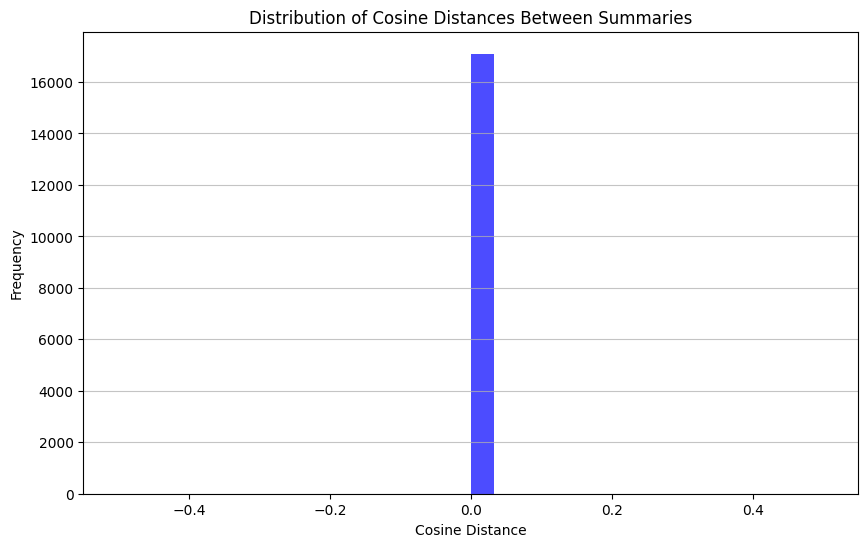

In [37]:
# plot the distances as histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_df['distance'], bins=30, alpha=0.7, color='blue')
plt.title('Distribution of Cosine Distances Between Summaries')
plt.xlabel('Cosine Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

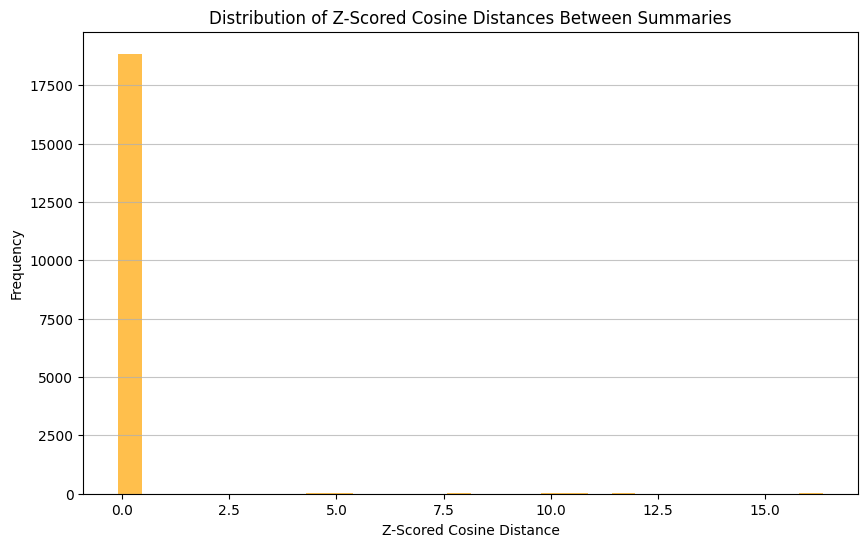

In [14]:
# plot the distance scores as histogram
plt.figure(figsize=(10, 6))
plt.hist(distances_df['distance_zscore'], bins=30, alpha=0.7, color='orange')
plt.title('Distribution of Z-Scored Cosine Distances Between Summaries')
plt.xlabel('Z-Scored Cosine Distance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [39]:
# select top 10 highest distance pairs
top_10 = ranked_df.head(10)
print("Top 10 most different summary pairs:")
print(top_10[['commit_hash', 'source_1', 'source_2', 'distance', 'distance_zscore']])

Top 10 most different summary pairs:
                                    commit_hash           source_1  \
0      052a0237b0e835481bd83be99d4ff40324e31f35  experiment-run_02   
11405  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_11   
11391  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11392  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11393  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11394  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11395  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11396  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11397  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   
11398  bf2b9895a6113aa61cf0c5a8c7612a7113f109bc  experiment-run_16   

                source_2  distance  distance_zscore  
0      experiment-run_05       0.0              NaN  
11405  experiment-run_08       0.0              NaN  
11391  experiment-run_11      

In [40]:
# print the summaries for the top 10 pairs
for idx, row in top_10.iterrows():
    print(f"\nCommit: {row['commit_hash']}")
    print(f"Source 1: {row['source_1']}")
    summary_1 = combined_df[(combined_df['commit hash'] == row['commit_hash']) & (combined_df['source_file'] == row['source_1'])]['semantic_summary'].values[0]
    print(f"Summary 1: {summary_1}")
    
    print(f"Source 2: {row['source_2']}")
    summary_2 = combined_df[(combined_df['commit hash'] == row['commit_hash']) & (combined_df['source_file'] == row['source_2'])]['semantic_summary'].values[0]
    print(f"Summary 2: {summary_2}")


Commit: 052a0237b0e835481bd83be99d4ff40324e31f35
Source 1: experiment-run_02
Summary 1: Implemented a new configuration handler for the MBE70 example, adding client and common settings with ForgeConfigSpec definitions. The README was updated to indicate the project is a work in progress and a new GUI entry was added for configuration. This refactoring improves configurability and documentation clarity, enabling easier setup and future development of the MBE70 module.
Source 2: experiment-run_05
Summary 2: Implemented a new configuration handler for the MBE70 example, adding client and common settings with ForgeConfigSpec definitions. The README was updated to indicate the project is a work in progress and a new GUI entry was added for configuration. This refactoring improves configurability and documentation clarity, enabling easier setup and future development of the MBE70 module.

Commit: bf2b9895a6113aa61cf0c5a8c7612a7113f109bc
Source 1: experiment-run_11
Summary 1: Implemented a n

In [18]:
# the commit 12d29fd7f02f16b97a3cbd718a478a71eb602b13 is one interesiting one, see if there are any further diiferences. Remove the commit
filtered_df = ranked_df[ranked_df['commit_hash']
                        != '12d29fd7f02f16b97a3cbd718a478a71eb602b13']
filtered_mean = filtered_df['distance'].mean()
filtered_std = filtered_df['distance'].std()
print(f"After removing outlier commit, mean: {filtered_mean:.4f}, std: {filtered_std:.4f}")

After removing outlier commit, mean: 0.0008, std: 0.0097


In [20]:
top_10 = filtered_df.head(10)

for idx, row in top_10.iterrows():
    print(f"\nCommit: {row['commit_hash']}")
    print(f"Source 1: {row['source_1']}")
    summary_1 = combined_df[(combined_df['commit hash'] == row['commit_hash']) & (
        combined_df['source_file'] == row['source_1'])]['semantic_summary'].values[0]
    print(f"Summary 1: {summary_1}")

    print(f"Source 2: {row['source_2']}")
    summary_2 = combined_df[(combined_df['commit hash'] == row['commit_hash']) & (
        combined_df['source_file'] == row['source_2'])]['semantic_summary'].values[0]
    print(f"Summary 2: {summary_2}")


Commit: 152e1a2aacaf1f7bcd474801e74a7aba1a78fd4e
Source 1: experiment-run_01
Summary 1: The commit removes a bug‑warning comment that incorrectly claimed the capability synchronization only worked in single player, clarifying that the code now supports multiplayer. The change is purely textual, updating documentation to reflect the fixed synchronization logic. This improves clarity for developers and ensures accurate information about multiplayer compatibility.
Source 2: experiment-run_13
Summary 2: The commit eliminates a false warning about a synchronization bug and cleans up an extraneous newline, simplifying the codebase. This change removes unnecessary diagnostic noise and tidies file formatting, improving maintainability without altering runtime behavior.

Commit: 152e1a2aacaf1f7bcd474801e74a7aba1a78fd4e
Source 1: experiment-run_16
Summary 1: The commit eliminates a false warning about a synchronization bug and cleans up an extraneous newline, simplifying the codebase. This chan